# Analyzing the Role of Socioeconomic Factors in Transportation & Health Outcomes:<br>
### _An NLP Approach_

## Introduction

### Background

* The social determinants of health (SDOH) are non-medical factors that can influence public health (WHO). <br>
* Factors based on <a href="https://www.annualreviews.org/content/journals/10.1146/annurev-publhealth-031210-101218">The Social Determinants of Health: Coming of Age</a> are: <br>
    * <u>Neighbourhood Conditions:</u> social + physical environments; individual health
    * <u>Working Conditions:</u> employment-related factors (the physical aspects of working as well as the work environment; psychosocial aspects; opportunities & resources)
    * <u>Education:</u> educational opportunities and the social & psychological factors associated
    * <u>Income & Wealth:</u> socioeconomic status, the environment one grows up with, and the resources they have access to
    * <u>Race & Racism:</u> racial disparities in health & healthcare
    * <u>Stress:</u> psychological stressors (their causes & effects)
* I have also identified common themes between these classifications, and made note of them, as follows: 

    * <u>Environment</u>: the physical landscape of the environment, services available, individual health, the physical aspects of work (eg muscle strain, back pain), the work environment (eg collaborative, desk space, etc), area demographics, economic hardship, racial discrimination, relative social status
    * <u>Social/Psychological</u>: social relationships, individual health, stress, subjective social status, self-perception
    * <u>Opportunities & Resources</u>: literacy, employment opportunities, literacy, income/wealth, education, social safety nets, Medicare, etc.
    * <u>Biological Effects</u>: release of cortisol & cytokines, ageing, disease
* Socioeconomic factors (SEFs) such as income, education, and employment play a crucial role in shaping transportation accessibility and health outcomes. 
* From the list above, we are interested in investigating **accessibility and transportation** which falls under the category of **Neighbourhood Conditions** because they are related to the social and physical environment people live in, which affects people's mobility and daily life activities
* Accessibility to transportation is also deeply tied with the other themes since socioeconomic status can affect vehicle ownership and access. Lack of transportation can cause psychological stress and increase daily burdens. Having limited transportation also limits access to healthcare, a solid education, and a stable job. All these factors affect people's overall well-being.

### Research Question

**Research Question**: Are research studies on public health more likely to mention transportation accessibility compared to other topics, and how is this relationship framed?

**Purpose**: to examine how accessibility to transportation is discussed in relation to public health by using NLP techniques to identify key themes, sentiment, and the frequency of associations in textual data from research studies

**Objectives:** <br>
1) To use NLP techniques to extract and categorize recurring themes in research studies discussing transportation accessibility and public health
2) To compare how often transportation is mentioned relative to other public health concerns (ie employment, education, income & wealth, race, and stress)
3) To analyze whether accessibility is discussed as a positive,  negative, or neutral factor in health outcomes
4) To identify patterns in how transportation is framed in relation to health (eg beneficial and improving healthcare access, or as a barrier and worsening disparities in health)

**Hypothesis**: Public health research studies are more likely to mention transportation accessibility compared to other social determinants of health, and they predominantly frame it as a positive factor for health outcomes.

In [2]:
# import packages
import spacy, re, nltk
import pandas as pd
import xml.etree.ElementTree as ET
import scipy

from collections import Counter

# NLP Packages
import gensim
import string
import re
import gensim.corpora as corpora
from scipy.linalg import triu
from gensim.models.ldamodel import LdaModel
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer



In [3]:
nlp = spacy.load("en_core_web_sm")

## Data Collection

### Data Acquisition Methods

* Collected 50 research articles about public health from the Internet and stored them in Mendeley Reference Manager
* Exported the references as a .xml file
* Stored the contents of the research articles each in a .txt file in an articles folder

## Data Processing and Preprocessing

### Text Data Preprocessing

In [4]:
# divide text into sections by label
def split_by_label(text, labels):
    pattern = '|'.join(re.escape(label) for label in labels)
    sections = re.split(pattern, text)
    return sections

In [5]:
# get the section labels for Article 1
labels = []
with open ('./articles/article1.txt', 'r') as file:
    for line in file:
        if line.strip() and not line.startswith((" ", "\t")):  # line is not indented
            labels.append(line.strip())
labels

['Abstract',
 'Health-care–related transportation insecurity is common in the',
 'United States. Patients with cancer are especially vulnerable',
 'because cancer care is episodic in nature, occurs over a',
 'prolonged period, is marked by frequent clinical encounters,',
 'requires intense treatments, and results in substantial',
 'financial hardship. As a result of transportation insecurity,',
 'patients with cancer may forego, miss, delay, alter, and/or',
 'prematurely terminate necessary care. Limited data suggest that',
 'these alterations in care have the potential to increase the',
 'rates of cancer recurrence and mortality and exacerbate',
 'disparities in cancer incidence, severity, and outcomes.',
 'Transportation insecurity also negatively impacts at the',
 'informal caregiver, provider, health system, and societal',
 'levels. Recognizing that transportation is a critical',
 'determinant of outcomes for patients with cancer, there are',
 'ongoing efforts to develop evidence-b

In [6]:
# placing the words from the article in a list / string
no_blanks = []
with open ('./articles/article1.txt', 'r') as f:
    lines = f.readlines()
    stripped_words = [[word.strip() for word in line.split() if len(word) > 0] for line in lines]
    for lst in stripped_words:
        if len(lst) > 0:
            no_blanks.append(lst)

In [7]:
# Stop Words
stop_words = set(stopwords.words("English"))

In [8]:
# Clean text - remove stopwords, punctuation, and special characters
def preprocess(word):
    word = re.sub(r"[^\w\s]", " ", word) # remove punctuation and special characters (anything that is not word or whitespace)
    word = re.sub(r"\d+", "", word) # remove numbers
    word = word.lower()
    if word not in stop_words:
        return word
    else:
        return ''

In [9]:
# cleaned text as a string
article_text = ' '.join([preprocess(word) for lst in no_blanks for word in lst])
article_text = ' '.join(article_text.split())
article_text



'abstract health care related transportation insecurity common united states patients cancer especially vulnerable cancer care episodic nature occurs prolonged period marked frequent clinical encounters requires intense treatments results substantial financial hardship result transportation insecurity patients cancer may forego miss delay alter and or prematurely terminate necessary care limited data suggest alterations care potential increase rates cancer recurrence mortality exacerbate disparities cancer incidence severity outcomes transportation insecurity also negatively impacts informal caregiver provider health system societal levels recognizing transportation critical determinant outcomes patients cancer ongoing efforts develop evidence based protocols identify at risk patients address transportation insecurity federal policy health system not for profit industry levels national cancer policy forum national academies science engineering medicine sponsored series webinars address

### Thematic Analysis

#### Named Entity Recognition

Let's investigate how common words fall in the categories of the social determinants of health and its related topics. The topics we will investigate in our text are:<br>
* **Social Determinants of Health:** the non-medical factors that influence a person's health (WHO)<br>
* **Health:** a person's physical, mental, and emotional well-being in a general sense, not necessarily related to the social determinants of health<br>
* **Privilege:** this may be mentioned a lot if SDOH is found to favor some people over others<br>
* **Socioeconomic status:** a measurement of where people stand socially or economically; this may be crucial to the social determinants of health<br>
* **Transportation:** we are interested in whether an association exists between transportation and the social determinants of health. By looking at positive/negative sentiment of the word along with topics related to privilege and socioeconomic status, we can get a better understanding of how inequalities in accessibility to transportation affect public health.<br>

In [10]:
sdoh_words = [
    "access", "poverty", "education", "employment", "housing", "nutrition", "environment", 
    "equity", "income", "stress", "safety", "transport", "literacy", "insurance", 
    "community", "resources", "disparity", "inequality", "lifestyle", "socioeconomic", 
    "healthcare", "discrimination", "segregation", "neighborhood", "accessibility", 
    "prevention", "opportunity", "advocacy", "wellness", "infrastructure", "support", 
    "inclusion", "participation", "mobility", "stability", "vulnerability", "diversity", 
    "integration", "outreach", "screening", "services", "policy", "networks", "empowerment", 
    "collaboration", "demographics", "risk", "culture", "barriers", "awareness"
]
sdoh_lemma = [word.lemma_ for word in nlp(' '.join(sdoh_words))]

In [11]:
transportation_words = [
    "accessibility", "affordability", "infrastructure", "mobility", "commuting",
    "public", "transit", "rail", "bus", "subway",
    "highway", "roadway", "intersection", "pedestrian", "cycling",
    "walkability", "connectivity", "urban", "rural", "traffic",
    "congestion", "emissions", "sustainability", "equity", "policy",
    "logistics", "ridesharing", "autonomous", "electric", "vehicle",
    "transport", "freight", "air", "maritime", "railway",
    "safety", "infrastructure", "planning", "development", "zoning",
    "land use", "mode", "alternative", "barriers", "disparities",
    "health", "environmental", "impact", "access", "efficiency"
]


In [12]:
def find_mentions(text, keywords):
    doc =  nlp(text)
    mentions = [token.text for token in doc if token.lower_ in keywords]
    entities = [ent.text for ent in doc.ents if ent.label_ in ['GPE', 'ORG', 'PERSON']]
    return mentions, entities
    

In [13]:
article_text

'abstract health care related transportation insecurity common united states patients cancer especially vulnerable cancer care episodic nature occurs prolonged period marked frequent clinical encounters requires intense treatments results substantial financial hardship result transportation insecurity patients cancer may forego miss delay alter and or prematurely terminate necessary care limited data suggest alterations care potential increase rates cancer recurrence mortality exacerbate disparities cancer incidence severity outcomes transportation insecurity also negatively impacts informal caregiver provider health system societal levels recognizing transportation critical determinant outcomes patients cancer ongoing efforts develop evidence based protocols identify at risk patients address transportation insecurity federal policy health system not for profit industry levels national cancer policy forum national academies science engineering medicine sponsored series webinars address

In [14]:
Counter(find_mentions(article_text, transportation_words)[0])

Counter({'health': 112,
         'policy': 30,
         'barriers': 13,
         'disparities': 12,
         'public': 11,
         'safety': 10,
         'access': 9,
         'development': 9,
         'infrastructure': 8,
         'rural': 7,
         'alternative': 5,
         'impact': 5,
         'bus': 2,
         'urban': 2,
         'equity': 1,
         'transit': 1,
         'vehicle': 1,
         'transport': 1,
         'logistics': 1,
         'planning': 1,
         'mobility': 1,
         'ridesharing': 1,
         'efficiency': 1})

In [15]:
Counter(find_mentions(article_text, sdoh_words)[1])

Counter({'medicaid': 16,
         'medicare': 12,
         'nemt': 5,
         'mtm': 5,
         'united states': 2,
         'emphysema lung': 1,
         'social determinants health disparities': 1,
         'continuum examine multilevel': 1,
         'continuum screening': 1,
         'american academy': 1,
         'illinois health s program': 1,
         'partnership university illinois health kaizen': 1})

#### LDA: Latent Dirichlet Allocation

In [16]:
no_blanks2 = []
with open ('./articles/article2.txt', 'r') as f:
    lines = f.readlines()
    stripped_words = [[word.strip() for word in line.split() if len(word) > 0] for line in lines]
    for lst in stripped_words:
        if len(lst) > 0:
            no_blanks2.append(lst)

In [17]:
# with just 2 articles
article_text2 = ' '.join([preprocess(word) for lst in no_blanks for word in lst])
article_text2 = ' '.join(article_text2.split())

In [18]:
Counter(find_mentions(article_text2, transportation_words)[0])

Counter({'health': 112,
         'policy': 30,
         'barriers': 13,
         'disparities': 12,
         'public': 11,
         'safety': 10,
         'access': 9,
         'development': 9,
         'infrastructure': 8,
         'rural': 7,
         'alternative': 5,
         'impact': 5,
         'bus': 2,
         'urban': 2,
         'equity': 1,
         'transit': 1,
         'vehicle': 1,
         'transport': 1,
         'logistics': 1,
         'planning': 1,
         'mobility': 1,
         'ridesharing': 1,
         'efficiency': 1})

In [19]:
Counter(find_mentions(article_text2, sdoh_words)[0])

Counter({'screening': 38,
         'policy': 30,
         'services': 15,
         'risk': 14,
         'barriers': 13,
         'safety': 10,
         'insurance': 10,
         'access': 9,
         'opportunity': 9,
         'housing': 8,
         'infrastructure': 8,
         'stress': 8,
         'participation': 8,
         'resources': 7,
         'income': 6,
         'inclusion': 5,
         'integration': 5,
         'employment': 4,
         'community': 4,
         'prevention': 2,
         'support': 2,
         'nutrition': 2,
         'equity': 1,
         'environment': 1,
         'neighborhood': 1,
         'transport': 1,
         'vulnerability': 1,
         'mobility': 1})

In [20]:
docs = [article_text, article_text2]


In [21]:
def preprocess_text(text):
    text = text.lower() 
    text = re.sub(r'\d+', '', text)  
    text = text.translate(str.maketrans('', '', string.punctuation)) 
    tokens = simple_preprocess(text)  # this function includes tokenize text!
    tokens = [word for word in tokens if word not in stop_words] 
    return tokens

In [22]:
little_processed_docs = [preprocess_text(doc) for doc in docs]

In [23]:
little_dictionary = corpora.Dictionary(little_processed_docs)

In [24]:
corpus = [little_dictionary.doc2bow(doc) for doc in little_processed_docs]

In [25]:
little_lda_model = LdaModel(
    corpus=corpus,
    id2word=little_dictionary,
    num_topics=5,
    random_state=42,
    passes=10,
    per_word_topics=True
)


In [26]:
topics = little_lda_model.print_topics(num_words=5)
for topic in topics:
    print(topic)

(0, '0.004*"transportation" + 0.003*"cancer" + 0.003*"insecurity" + 0.003*"health" + 0.003*"patients"')
(1, '0.003*"transportation" + 0.003*"cancer" + 0.003*"insecurity" + 0.002*"patients" + 0.002*"care"')
(2, '0.004*"transportation" + 0.003*"cancer" + 0.002*"patients" + 0.002*"insecurity" + 0.002*"health"')
(3, '0.007*"transportation" + 0.006*"cancer" + 0.005*"patients" + 0.004*"insecurity" + 0.004*"health"')
(4, '0.044*"transportation" + 0.037*"cancer" + 0.026*"insecurity" + 0.024*"patients" + 0.021*"health"')


In [27]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

little_lda_display = gensimvis.prepare(little_lda_model, corpus, little_dictionary)
pyLDAvis.display(little_lda_display)

In [28]:
import os
all_docs = []

# extract the text for all the articles
for article in os.listdir('./articles/'):
    text = []
    with open (f'./articles/{article}', 'r') as f:
        lines = f.readlines()
        stripped_words = [[word.strip() for word in line.split() if len(word) > 0] for line in lines]
        for lst in stripped_words:
            if len(lst) > 0:
                text.append(lst)
        
    article_text_str = ' '.join([preprocess(word) for lst in stripped_words for word in lst])
    article_text_str = ' '.join(article_text_str.split())
    all_docs.append(article_text_str)

In [29]:
all_docs

['abstract although cancer mortality rates declined united states recent decades populations experienced little benefit advances cancer prevention early detection treatment survivorship care fact cancer disparities populations low high socioeconomic status widened period many potentially preventable cancer deaths continue occur disadvantaged populations bear disproportionate burden reducing burden cancer eliminating cancer related disparities require focused coordinated action across multiple sectors partnership communities article part american cancer society s cancer control blueprint series introduces framework understanding addressing social determinants advance cancer health equity presents actionable recommendations practice research policy article aims accelerate progress toward eliminating disparities cancer achieving health equity introduction field cancer control crossroads despite progress cancer united states progress equitably benefitted population groups overall cancer de

In [30]:
processed_docs = [preprocess_text(doc) for doc in all_docs]

In [31]:
dictionary = corpora.Dictionary(processed_docs)

In [32]:
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

In [33]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=15,
    random_state=42,
    passes=10,
    per_word_topics=True
)

In [34]:
topics = lda_model.print_topics(num_words=5)
for topic in topics:
    print(topic)

(0, '0.002*"health" + 0.001*"social" + 0.001*"transportation" + 0.001*"cancer" + 0.001*"care"')
(1, '0.001*"health" + 0.001*"transportation" + 0.000*"social" + 0.000*"care" + 0.000*"cancer"')
(2, '0.022*"health" + 0.022*"diabetes" + 0.015*"social" + 0.015*"sdoh" + 0.013*"care"')
(3, '0.006*"health" + 0.005*"cancer" + 0.004*"social" + 0.003*"patients" + 0.002*"transportation"')
(4, '0.002*"health" + 0.001*"transportation" + 0.001*"social" + 0.001*"cancer" + 0.001*"patients"')
(5, '0.002*"health" + 0.002*"social" + 0.001*"traffic" + 0.001*"transportation" + 0.001*"diabetes"')
(6, '0.002*"health" + 0.001*"social" + 0.001*"transportation" + 0.001*"care" + 0.001*"cancer"')
(7, '0.002*"health" + 0.001*"transportation" + 0.001*"social" + 0.001*"care" + 0.001*"cancer"')
(8, '0.033*"health" + 0.027*"social" + 0.026*"cancer" + 0.012*"care" + 0.011*"determinants"')
(9, '0.025*"traffic" + 0.014*"health" + 0.013*"social" + 0.013*"exposure" + 0.010*"et"')
(10, '0.001*"health" + 0.001*"social" + 0.00

In [35]:
lda_display = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(lda_display)

In [36]:
from gensim.models import CoherenceModel

coherence_model_score = CoherenceModel(model = lda_model, texts = processed_docs, dictionary = dictionary, coherence = 'u_mass')
coherence_model_score.get_coherence()

-0.31894436747008054

In [37]:
print(f'Log Perplexity Score: {lda_model.log_perplexity(corpus)}')
# coherence: -0.391
# perplexity: -7.467

Log Perplexity Score: -7.379848137441972


**Coherence Score**: -0.391 < 0 --> relatively low; room for improvement
* May indicate the topics are not very coherent because the topics are not well-defined or are overlapping, don't capture meaningful semantic relationships, or there may be too many or too few topics for the dataset<br>
**Log Perplexity Score**: -7.467 --> perplexity = e^(-7.467) = 0.00057
* Low perplexity scores are generally good, but extremely low log perplexity scores may indicate overfitting if the model is too complex or the dataset is too small

#### Keyword Extraction

In [38]:
# imports
import string
from sklearn.feature_extraction.text import TfidfVectorizer

In [39]:
# TF-IDF
# initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=1_000)
tfidf_matrix = vectorizer.fit_transform(all_docs)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.head()

,ability,able,aboriginal,access,accessibility,accessible,account,accountable,achieve,achieving,...,work,workers,working,worse,would,yarning,year,years,yet,you
0,0.011239,0.008288,0.0,0.079985,0.000000,0.000000,0.009229,0.009229,0.018458,0.018458,...,0.020641,0.004144,0.002826,0.000000,0.000000,0.0,0.003098,0.000000,0.018587,0.0
1,0.003791,0.000000,0.0,0.039160,0.004669,0.002335,0.002335,0.009338,0.007004,0.014007,...,0.015664,0.008386,0.005719,0.012005,0.004289,0.0,0.003135,0.006884,0.001567,0.0
2,0.000000,0.003515,0.0,0.124736,0.000000,0.000000,0.000000,0.000000,0.003914,0.000000,...,0.015318,0.017574,0.019175,0.000000,0.002397,0.0,0.007882,0.023082,0.007882,0.0
3,0.027574,0.000000,0.0,0.037982,0.000000,0.042455,0.000000,0.016982,0.025473,0.000000,...,0.009495,0.000000,0.005200,0.000000,0.010400,0.0,0.005700,0.025038,0.005700,0.0
4,0.000000,0.000000,0.0,0.035615,0.042464,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.017808,0.000000,0.003251,0.000000,0.003251,0.0,0.000000,0.000000,0.010691,0.0


In [40]:
top_n = 10
top_words = []
for i, text in enumerate(all_docs):
    top_words.append([])
    top_n_words = tfidf_matrix[i].toarray().argsort()[0][-10:] # get indices of top 10 words
    top_words[i] = ([vectorizer.get_feature_names_out()[i] for i in top_n_words]) # get the words from the indices

In [84]:
all_docs

['abstract although cancer mortality rates declined united states recent decades populations experienced little benefit advances cancer prevention early detection treatment survivorship care fact cancer disparities populations low high socioeconomic status widened period many potentially preventable cancer deaths continue occur disadvantaged populations bear disproportionate burden reducing burden cancer eliminating cancer related disparities require focused coordinated action across multiple sectors partnership communities article part american cancer society s cancer control blueprint series introduces framework understanding addressing social determinants advance cancer health equity presents actionable recommendations practice research policy article aims accelerate progress toward eliminating disparities cancer achieving health equity introduction field cancer control crossroads despite progress cancer united states progress equitably benefitted population groups overall cancer de

In [41]:
for i in range(len(top_words)):
    print(f'Article {i + 1}: {top_words[i]}')

Article 1: ['focused', 'disparities', 'address', 'determinants', 'patients', 'care', 'disadvantaged', 'social', 'health', 'cancer']
Article 2: ['hbac', 'prevalence', 'adults', 'food', 'care', 'social', 'sdoh', 'tdm', 'health', 'diabetes']
Article 3: ['family', 'services', 'access', 'group', 'mongolia', 'district', 'strategy', 'social', 'red', 'health']
Article 4: ['usa', 'physicians', 'cancer', 'social', 'health', 'ocm', 'programmes', 'oncologists', 'sdoh', 'patients']
Article 5: ['arterials', 'physical', 'streets', 'transportation', 'land', 'roads', 'health', 'social', 'arterial', 'traffic']
Article 6: ['bus', 'that', 'know', 've', 'indigenous', 'it', 'people', 'participants', 'transport', 'aboriginal']
Article 7: ['health', 'oncology', 'interventions', 'patients', 'insecurity', 'risk', 'trial', 'oncologists', 'cancer', 'sdoh']
Article 8: ['need', 'among', 'screening', 'treatment', 'care', 'health', 'patients', 'insecurity', 'transportation', 'cancer']
Article 9: ['handydart', 'aging'

In [42]:
# average TF-IDF
avg_tfidf_scores = tfidf_df.mean().sort_values(ascending=False)

top_n = 20
avg_tfidf_scores.head(top_n)


health            0.239573
cancer            0.152517
social            0.146675
sdoh              0.123178
transportation    0.122097
patients          0.114945
traffic           0.104142
care              0.098683
diabetes          0.071873
insecurity        0.062009
outcomes          0.056209
al                0.052401
et                0.052401
aboriginal        0.052260
community         0.047780
adults            0.047760
access            0.047292
oncologists       0.046338
older             0.045708
exposure          0.042143
dtype: float64

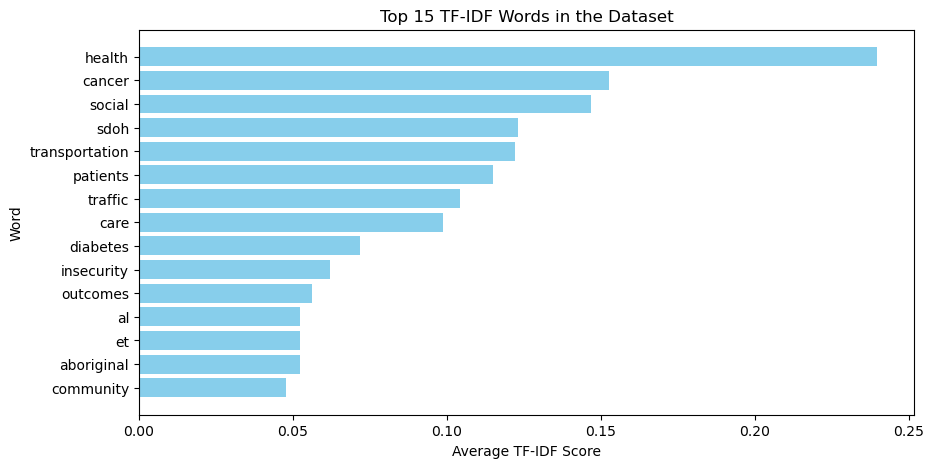

In [43]:
import matplotlib.pyplot as plt

# Get top words and scores
top_words = avg_tfidf_scores.head(15)
plt.figure(figsize=(10, 5))
plt.barh(top_words.index[::-1], top_words.values[::-1], color='skyblue')
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Word")
plt.title("Top 15 TF-IDF Words in the Dataset")
plt.show()


TF-IDF is a combination of term frequency (TF) and inverse document frequency (IDF).
* **Term Frequency (TF)**: measures how often a word appears in a document. However, it may not tell us if the word is rare or important _across all documents_. For example, if "transportation" appears in 90% of the documents, it is not very significant if we are only using TF. Another example are common words such as "the" or "and", which may appear in most documents, but hold little significance. 
* **Inverse Document Frequency (IDF)**: since some words are very common but have little significance, IDF reduces the weight of common words and increases the weight of rare words. This is because rare words are more likely to be meaningful and specific. IDF is calculated by taking the log of (total number of items in corpus D) / (number of documents containing term t)

**Key Observations**:
- 'Health' has the highest TF-IDF score, which means that it is a very prominent and significant theme across all the documents.
- 'Cancer', 'social', 'SDOH', and 'transportation', also rank in the top five for highest TF-IDF, which demonstrates that some topics that are significant to the topic of social determinants of health include terminal illness, social climbing, and accessibility to transportation. There must be some kind of significant relationship interwtwining these three topics. For example, people who are higher up the social ladder may have greater accessibility to transportation and are more likely to be treated for their disease or illness, such as cancer, compared to those from a lower socioeconomic class. 
- 'Transportation' and 'traffic' both appear in the top 15 for highest TF-IDF, which suggests meaningful discussions on congestion, mobility, and/or their impact on public health.
- Earlier, we defined some common themes found from the research articles about the social determinants of health: environment, social/psychological, opportunities/resources, and biological effects. We can sort the top 15 words into the common themes as follows, excluding 'et' and 'al', as those are most likely from citations and can be ignored:
  - Biological Effects: 'health', 'cancer', 'patients', 'diabetes'
  - Social/Psychological: 'social', 'sdoh', 'insecurity', 'aboriginal', 'community'
  - Opportunities/Resources: 'transportation', 'traffic', 'care' (healthcare access)

**Takeaways**:
- Words like 'health', 'cancer', 'diabetes', and 'patients' suggest that the dataset heavily focuses on health conditions and medical outcomes.
- The presence of 'social', 'SDOH', 'insecurity', 'community', and 'aboriginal' indicates that many articles discuss broader social and psychological factors affecting health.
- Transportation may not be discussed in isolation but _as a larger social issue_ involving social inequalities and disparities in public health
- 'Transportation' and 'traffic' both have high TD-IDF but are not at the very top, which supports the idea that these topics are common but not the primary focus. Instead, they are probably discussed in connection with other social and health issues

#### NER: Named Entity Recognition

In [44]:
from collections import Counter

entity_counter = Counter()

# most common entities for locations, organizations, and people
for text in all_docs:
    doc = nlp(text)
    entities = [ent.text.lower() for ent in doc.ents if ent.label_ in {"GPE", "ORG", "FAC", "PERSON", "EVENT"}]
    entity_counter.update(entities)

entity_counter.most_common(20)



[('al', 57),
 ('medicaid', 27),
 ('denver', 22),
 ('medicare', 18),
 ('united states', 9),
 ('social determinants health', 6),
 ('california', 5),
 ('graffiti', 5),
 ('nemt', 5),
 ('mtm', 5),
 ('williams', 5),
 ('al houston', 5),
 ('aca', 4),
 ('medicare medicaid', 4),
 ('al rowangould', 4),
 ('tian', 4),
 ('fig', 3),
 ('ada', 3),
 ('eric', 3),
 ('british columbia', 3)]

The biggest topics (locations, orgaizations, people, events) discussed are related to Medicaid & Medicare - accessibility to health.

### Comparing Transportation Mentions

In [45]:
# from earlier in the code
transportation_words = [
    "accessibility", "affordability", "infrastructure", "mobility", "commuting",
    "public", "transit", "rail", "bus", "subway",
    "highway", "roadway", "intersection", "pedestrian", "cycling",
    "walkability", "connectivity", "urban", "rural", "traffic",
    "congestion", "emissions", "sustainability", "equity", "policy",
    "logistics", "ridesharing", "autonomous", "electric", "vehicle",
    "transport", "freight", "air", "maritime", "railway",
    "safety", "infrastructure", "planning", "development", "zoning",
    "land use", "mode", "alternative", "barriers", "disparities",
    "health", "environmental", "impact", "access", "efficiency"
]


Other Public Health Concerns

In [46]:
health_words = [
    "health", "cancer", "patients", "diabetes", "treatment", "therapy", "disease", "prevention", "risk", "mortality",
    "screening", "diagnosis", "biomarker", "insulin", "glucose", "obesity", "lifestyle", "epidemiology", "survival", "remission",
    "oncology", "chemotherapy", "radiotherapy", "metastasis", "tumor", "genetics", "mutation", "biopsy", "prognosis", "complication",
    "symptoms", "management", "clinical", "trials", "intervention", "metabolism", "cardiovascular", "neuropathy", "autoimmune", "inflammation",
    "endocrinology", "nutrition", "exercise", "glycemic", "hormones", "pancreas", "diagnostic", "public", "epigenetics", "morbidity"
]

In [47]:
social_words = [
    "equity", "disparities", "marginalization", "inclusion", "exclusion",
    "stigma", "discrimination", "accessibility", "barriers", "wellbeing",
    "intersectionality", "inequality", "vulnerability", "empowerment", "autonomy",
    "resilience", "support", "cohesion", "advocacy", "integration",
    "participation", "justice", "poverty", "housing", "nutrition",
    "education", "employment", "oppression", "healthcare", "trauma",
    "historical", "colonialism", "identity", "belonging", "culture",
    "heritage", "ethnicity", "indigeneity", "language", "tradition",
    "mental", "psychosocial", "isolation", "exploitation", "prejudice",
    "socioeconomic", "displacement", "safety", "harassment", "network"
]



In [48]:
opportunity_words = [
    "accessibility", "mobility", "infrastructure", "equity", "efficiency", 
    "availability", "affordability", "coverage", "proximity", "capacity", 
    "integration", "connectivity", "routes", "network", "transit", 
    "frequency", "scheduling", "multimodal", "safety", "convenience", 
    "innovation", "technology", "optimization", "funding", "policy", 
    "investment", "sustainability", "navigation", "planning", "expansion", 
    "inclusion", "barriers", "solutions", "partnerships", "coordination", 
    "incentives", "efficacy", "utilization", "intervention", "regulation", 
    "reliability", "resilience", "access", "distribution", "services", 
    "facilities", "coverage", "health", "wellness", "transport"
]



In [49]:
topics_list = [transportation_words, health_words, social_words, opportunity_words]

In [50]:
topic_lemmas = {topic_name: [word.lemma_ for word in nlp(' '.join(words))] 
                for topic_name, words in zip(["transportation", "Health", "Social", "Opportunities"], topics_list)}

In [51]:
topic_count_dict = {topic: [] for topic in topic_lemmas}
processed_docs = [nlp(doc) for doc in all_docs]
for doc in processed_docs:  
    lemma_text = [word.lemma_ for word in doc if word.is_alpha and not word.is_stop]
    word_counts = Counter(lemma_text)

    # Compute counts for each topic
    for topic, lemma_list in topic_lemmas.items():
        topic_count = sum(word_counts[key] for key in word_counts if key in lemma_list)
        topic_count_dict[topic].append((topic_count / len(lemma_text) * 100) if len(lemma_text) > 0 else 0)
topic_count_dict

{'transportation': [7.27470141150923,
  5.205622071837585,
  8.855060034305318,
  4.577656675749319,
  12.629226040793517,
  6.240668856375038,
  4.362050163576881,
  5.260011954572624,
  9.381413075344474,
  9.411989308896525],
 'Health': [10.22801302931596,
  7.496095783446122,
  5.939108061749572,
  10.626702997275205,
  3.548477228276055,
  1.0749477455957002,
  16.466739367502726,
  14.70412432755529,
  3.5766637349750807,
  2.0236731576937763],
 'Social': [4.299674267100977,
  3.3055700156168664,
  1.7367066895368783,
  3.4877384196185286,
  2.5146689019279127,
  1.7318602567930725,
  3.162486368593239,
  1.7134887427774457,
  1.2606273819994136,
  2.6345933562428407],
 'Opportunities': [8.403908794788274,
  5.687142113482562,
  10.441680960548885,
  4.741144414168938,
  5.755797708857223,
  5.046282472379815,
  6.2159214830970555,
  5.638573421000199,
  7.211961301671065,
  3.3218785796105386]}

[show spreadsheet table]

* 4/10 articles were primarily about transportation
* 5/10 articles were primarily about health
* 1/10 articles were primarily about opportunities and resources 
* Health was mentioned the most overall and had its highest value in Article 7 (16.47% of the words in the article were related to health) Other high mentions of health were in Article 8 (14.7%) and Article 4 (10.63%). 
* Transportation and health were widely discussed topics, making a significant appearance in half the articles each. However, most of the articles appear to minimally discuss social factors
* Many of the "social" values are quite low, often below 4.0.
* The highest mention of social values appears in Article 1 at 4.3% and mostly is rare across all the texts. 
* Since 'social' has such low frequencies, it is not a prevalent topic. We will further look into comparing transportation with health or opportunities. 


### Word Embeddings

[explain what word embeddings and BERT are]

We will use BERT for classification (sentiment analysis). <br>
**Goal**: Classify the text into positive/negative/neutral categories by adding a classification layer on top of the transformer output for the CLS token

[discuss math]

In [52]:
from sentence_transformers import SentenceTransformer, util

In [53]:
for article in os.listdir('./articles/'):
    sentences_text = []
    with open (f'./articles/{article}', 'r') as f:
        lines = f.readlines()
        for line in lines:
            sentences = nltk.sent_tokenize(line) # split into sentences
            for sentence in sentences: 
                stripped_words = [word.strip() for word in sentence.split() if len(word) > 0]
                if len(stripped_words) > 0:
                    sentences_text.append(stripped_words)
        
sentences_text = [' '.join(text) for text in sentences_text]
sentences_text

['ABSTRACT',
 'Transportation systems generate certain health-promoting benefits such as access to social, economic, and',
 'cultural resources, but they also are a source of air pollution, noise, safety hazards, and barriers that',
 'diminish social cohesion in neighborhoods.',
 'Streets, in particular, are among the most important forms of',
 'public space in cities, yet they also are a main source of exposure to the negative externalities of traffic.',
 'It',
 'is estimated that between 4 and 19 percent of the U.S. population lives close to high-traffic roads,',
 'depending on assumptions about distance and types of roadway.',
 'These proportions are higher for',
 'minority and low-income populations.',
 'Although the relationships between traffic exposure, race, and',
 'socio-economic status have been consistent and reproducible, they have also been spatially heterogeneous',
 'with limited investigation into the patterns or causes of the heterogeneity.',
 'Using spatially-explicit'

In [54]:
def combine_lines(sentences):
    combined_sentences = []
    temp_sentence = ""
    for line in sentences:
        if line[-1] in ['.', '?', '!']:  # Sentence ends here
            temp_sentence += " " + line.strip()
            combined_sentences.append(temp_sentence.strip())
            temp_sentence = ""
        else:
            temp_sentence += " " + line.strip()
    if temp_sentence:  # In case there's a final sentence without punctuation
        combined_sentences.append(temp_sentence.strip())
    return combined_sentences

In [55]:
new_sentences = combine_lines(sentences_text)

In [56]:
# model = SentenceTransformer('all-MiniLM-L6-v2')  
# text5 = []
# with open (f'./articles/article5.txt', 'r') as f:
#     lines = f.readlines()
#     for line in lines:
#         sentences = nltk.sent_tokenize(line) # split into sentences
#         for sentence in sentences: 
#             stripped_words = [word.strip() for word in sentence.split() if len(word) > 0]
#             if len(stripped_words) > 0:
#                 text5.append(stripped_words)
# text5_sentences = [' '.join(text) for text in text5] # a list of sentences from Article 5, where every item in the list is an individual sentence
# # We use Article 5 because that article had the greatest percentage of mentions of transportation

In [57]:
# adds the special [CLS] (classification) and [SEP] (separator) tokens at the beginning and end of the encoded sequence 
model = SentenceTransformer('all-MiniLM-L6-v2')  
embeddings = model.encode(new_sentences, convert_to_tensor=True)
embeddings

tensor([[ 0.0997, -0.0236,  0.0580,  ...,  0.0933, -0.0489,  0.0226],
        [ 0.1287, -0.0297,  0.1129,  ...,  0.0472, -0.0525,  0.0398],
        [ 0.1171, -0.1530,  0.0359,  ...,  0.0214,  0.0078,  0.0184],
        ...,
        [ 0.0928, -0.0025,  0.0202,  ...,  0.0416,  0.0044, -0.0242],
        [ 0.0719, -0.0643,  0.1305,  ...,  0.0997, -0.0388,  0.0041],
        [ 0.0162,  0.0759, -0.0360,  ...,  0.0095, -0.0322, -0.0257]],
       device='mps:0')

In [58]:
# cosine similarity between all pairs of sentence embeddings
similarity_matrix = util.pytorch_cos_sim(embeddings,embeddings)
similarity_matrix

tensor([[ 1.0000,  0.5889,  0.4408,  ...,  0.3046,  0.4715, -0.0297],
        [ 0.5889,  1.0000,  0.4545,  ...,  0.2966,  0.5516, -0.0618],
        [ 0.4408,  0.4545,  1.0000,  ...,  0.2263,  0.4261,  0.0761],
        ...,
        [ 0.3046,  0.2966,  0.2263,  ...,  1.0000,  0.1944, -0.0261],
        [ 0.4715,  0.5516,  0.4261,  ...,  0.1944,  1.0000, -0.0275],
        [-0.0297, -0.0618,  0.0761,  ..., -0.0261, -0.0275,  1.0000]],
       device='mps:0')

In [59]:
from sklearn.cluster import KMeans
import numpy as np

In [60]:
np_embeddings = embeddings.cpu().numpy()
np_embeddings

array([[ 0.09965932, -0.02364282,  0.05795882, ...,  0.09330207,
        -0.04888413,  0.02257014],
       [ 0.12873328, -0.0297437 ,  0.11289866, ...,  0.04717169,
        -0.05251733,  0.03983229],
       [ 0.11708422, -0.15301414,  0.03590973, ...,  0.02136891,
         0.00782326,  0.0183506 ],
       ...,
       [ 0.09284972, -0.00245469,  0.02022587, ...,  0.04159002,
         0.00436334, -0.02424929],
       [ 0.07192546, -0.06433552,  0.13046096, ...,  0.09966682,
        -0.03880973,  0.00410838],
       [ 0.01620844,  0.07585352, -0.03604541, ...,  0.00947789,
        -0.03224201, -0.02572525]], dtype=float32)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity as cosine_sim
import umap.umap_ as umap
from sklearn.cluster import KMeans
from itertools import cycle
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Reduce dimensionality
reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, metric='cosine')
embeddings_2d = reducer.fit_transform(np_embeddings)

clusters = 5
kmeans = KMeans(n_clusters=clusters,random_state=42)
cluster_labels = kmeans.fit_predict(embeddings_2d)
cluster_group = {}

for i, sentence in enumerate(new_sentences):
    cluster_id = cluster_labels[i]
    if cluster_id not in cluster_group:
        cluster_group[cluster_id] = [sentence]
    else:
        cluster_group[cluster_id].append(sentence)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [62]:
cluster_group[4]

['ii TABLE OF CONTENTS 1.',
 'INTRODUCTION................................................................................................................... 1 2.',
 'DATA AND METHODS ........................................................................................................ 7 3.1 Study Area ....................................................................................................................................... 7 3.2 Data Sources .................................................................................................................................... 8 3.3 Analytical Approach ........................................................................................................................ 9 3.3.1 Estimation of the Traffic (Exposure) Surface ........................................................................ 9 3.3.2 Extraction of Exposure to Block Groups ............................................................................... 9 3.3.

Text(0.5, 1.0, 'BERT Sentence Embeddings (UMAP Projection)')

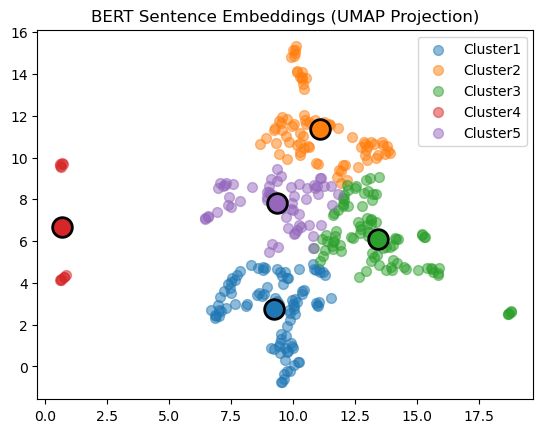

In [63]:
# Find centroids
centroids_2d = kmeans.cluster_centers_

# Plot embeddings
labels = {i: f'Cluster{i + 1}' for i in range(clusters)}

colors = cycle(cm.tab10.colors)
plt.figure()

for i in range(clusters):
    # plot one cluster for each iteration
    color = next(colors)
    # find indices corresponding to cluser i
    idx = cluster_labels == i
    # plot clusters
    plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], color=[color], s=50, label=labels[i], alpha=0.5)
    # plot centroids
    plt.scatter(centroids_2d[i, 0], centroids_2d[i, 1], edgecolors="k", linewidth=2, color=color, s=200, alpha=1)
plt.legend()
plt.title("BERT Sentence Embeddings (UMAP Projection)")


In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
# TF-IDF
# initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
docs = [preprocess(word) for word in new_sentences]
X = vectorizer.fit_transform(docs)

# K means Clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(X)
y_hat = kmeans.predict(X)

feature_names = np.array(vectorizer.get_feature_names_out())

for i in range(n_clusters):
    cluster_index = np.where(y_hat == i)[0]
    cluster_words = []
    for j in cluster_index:
        words = docs[j].split()
        filtered_words = [word for word in words if word not in ENGLISH_STOP_WORDS]
        cluster_words.extend(filtered_words)

    word_counts = Counter(cluster_words)
    print(f"Most common words in Cluster {i + 1}:")
    most_common = word_counts.most_common(5)  # Adjust the number (5) as necessary
    for word, count in most_common:
        print(f"{word}: {count}")

Most common words in Cluster 1:
region: 11
area: 11
figure: 11
traffic: 10
housing: 10

Most common words in Cluster 2:
traffic: 49
exposure: 33
spatial: 30
block: 25
poverty: 23

Most common words in Cluster 3:
health: 39
social: 30
transportation: 29
traffic: 29
use: 27

Most common words in Cluster 4:
et: 63
al: 63
traffic: 17
health: 13
high: 10

Most common words in Cluster 5:
traffic: 58
exposure: 47
block: 27
high: 20
areas: 18



### Sentiment Analysis

In [65]:
# TF-IDF
# initialize TF-IDF vectorizer
new_sentences

['ABSTRACT Transportation systems generate certain health-promoting benefits such as access to social, economic, and cultural resources, but they also are a source of air pollution, noise, safety hazards, and barriers that diminish social cohesion in neighborhoods.',
 'Streets, in particular, are among the most important forms of public space in cities, yet they also are a main source of exposure to the negative externalities of traffic.',
 'It is estimated that between 4 and 19 percent of the U.S. population lives close to high-traffic roads, depending on assumptions about distance and types of roadway.',
 'These proportions are higher for minority and low-income populations.',
 'Although the relationships between traffic exposure, race, and socio-economic status have been consistent and reproducible, they have also been spatially heterogeneous with limited investigation into the patterns or causes of the heterogeneity.',
 'Using spatially-explicit statistical techniques, we examined 

### Sentiment Analysis

In this section, we will analyze whether accessibility to public transportation is discussed as a positive, negative, or neutral factor to public health.

In [66]:
# IMPORT RELEVANT PACKAGES
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [67]:
# EXAMPLE OF SENTIMENT ANALYSIS

analyzer = SentimentIntensityAnalyzer()
text = "Accessible public transportation greatly improves patient access to healthcare services."
score = analyzer.polarity_scores(text)
score


{'neg': 0.0, 'neu': 0.744, 'pos': 0.256, 'compound': 0.4754}

This above example sentence is mostly neutral but has some slightly positive sentiment, leaving it with a compound sentiment score of 0.4754. This is likely because of the "greatly improves" in the sentence.

In [87]:
new_sentences

['ABSTRACT Transportation systems generate certain health-promoting benefits such as access to social, economic, and cultural resources, but they also are a source of air pollution, noise, safety hazards, and barriers that diminish social cohesion in neighborhoods.',
 'Streets, in particular, are among the most important forms of public space in cities, yet they also are a main source of exposure to the negative externalities of traffic.',
 'It is estimated that between 4 and 19 percent of the U.S. population lives close to high-traffic roads, depending on assumptions about distance and types of roadway.',
 'These proportions are higher for minority and low-income populations.',
 'Although the relationships between traffic exposure, race, and socio-economic status have been consistent and reproducible, they have also been spatially heterogeneous with limited investigation into the patterns or causes of the heterogeneity.',
 'Using spatially-explicit statistical techniques, we examined 

In [68]:
from sentence_transformers import SentenceTransformer, util
from nltk.sentiment import SentimentIntensityAnalyzer

model = SentenceTransformer('all-MiniLM-L6-v2') # SBERT converts each sentence into a vector representation
sia = SentimentIntensityAnalyzer()

sentences = new_sentences
query = "transportation accessibility, health" # --> also converted into a vector representation

# Embeddings
sentence_embeddings = model.encode(sentences, convert_to_tensor=True)
query_embedding = model.encode(query, convert_to_tensor=True)

similarities = util.pytorch_cos_sim(query_embedding, sentence_embeddings)[0] # cosine measure how similar the query is to the sentence

# Threshold for similarity
threshold = 0.5  

accessibility_related_sentences = [
    sentences[i] for i in range(len(sentences)) if similarities[i] > threshold
]
accessibility_related_sentences


['ABSTRACT Transportation systems generate certain health-promoting benefits such as access to social, economic, and cultural resources, but they also are a source of air pollution, noise, safety hazards, and barriers that diminish social cohesion in neighborhoods.',
 'This study focused on a ubiquitous transportation outcome of these land use decisions—how transportation and land use, working together, influence residents’ exposure to traffic.',
 'Exposure to high traffic volumes can lead to adverse health outcomes such as respiratory disease, cardiovascular disease, adverse birth outcomes, injury, and depression (Anderson et al., 2012; Babisch, 2014; Gee and Takeuchi, 2004; Morency et al., 2012; Sapkota et al., 2010; Song et al., 2007).',
 'In addition, high traffic volumes are a known barrier to walking, bicycling, and access to transit, and a contributor to diminished social capital in neighborhoods (Anciaes et al., 2016; Appleyard and Lintell, 1972; LoukaitouSideris, 2006).',
 'Th

In [69]:
sentiment = []
for sentence in accessibility_related_sentences:
    scores = sia.polarity_scores(sentence)
    compound_score = scores['compound']
    sentiment.append(compound_score)

np.mean(sentiment)

-0.11456666666666668

Since the mean sentiment score of all sentences related to transportation accessibility and health is below 0 (-0.115), on average, there is slight negative sentiment in the text when discussing accesibility. 

In [70]:
len([score for score in sentiment if score >= 0.5])

2

In [71]:
len([score for score in sentiment if score < 0.05 and score > -0.05])

7

In [72]:
[score for score in sentiment if score <= -0.05]

[-0.8885,
 -0.128,
 -0.128,
 -0.5499,
 -0.4215,
 -0.5106,
 -0.3007,
 -0.25,
 -0.6908,
 -0.296,
 -0.4215,
 -0.4215,
 -0.7184,
 -0.9274]

* 14/23 accessibility/health sentences had negative sentiment
* 7/23 accessibility/health sentences had neutral sentiment
* 2/23 accessibility/health sentences had positive sentiment
* The sentences with negative sentiment had an average sentiment score of -0.475 (moderately negeative)

_Why is accessibility in relation to health outcomes being discussed so negatively?_

In [73]:
negative_indices = [index for index, score in enumerate(sentiment) if score <= -0.05 ]

In [74]:
negative_sentences = []
for i in negative_indices:
    negative_sentences.append(accessibility_related_sentences[i])
negative_sentences

['Exposure to high traffic volumes can lead to adverse health outcomes such as respiratory disease, cardiovascular disease, adverse birth outcomes, injury, and depression (Anderson et al., 2012; Babisch, 2014; Gee and Takeuchi, 2004; Morency et al., 2012; Sapkota et al., 2010; Song et al., 2007).',
 'In addition, high traffic volumes are a known barrier to walking, bicycling, and access to transit, and a contributor to diminished social capital in neighborhoods (Anciaes et al., 2016; Appleyard and Lintell, 1972; LoukaitouSideris, 2006).',
 'In addition, high traffic volumes are a known barrier to walking, bicycling, and access to transit, and a contributor to community severance and diminished social capital (Anciaes et al., 2016; LoukaitouSideris, 2006; Appleyard and Lintell, 1972).',
 'These exposures are known social-ecological pathways that affect health and health disparities, but traffic on streets is rarely considered a factor in social problems.',
 'The next sections situate tr

1) high traffic --> disease, adverse birth outcomes, injuries, depression
2) high traffic --> barriers to micromobility, public transit, community
3) high traffic --> barriers to micromobility, public transit, community
4) health, health disparities BUT rarely affects social problems
5) stress + traffic --> health
6) related to SDOH: poverty & segregation, neighborhood social & physical environments, health outcomes
7) not much research & understanding on how traffic, streets, land --> health socially
8) stress, affects health in urban & non-metropolitan places
9) requires a deep & sophisticated understanding of public space & transportation 
10) limited knowledge on how social impacts of transportation interact with health 
11) social impacts of transportation to health: chronic stress, behavior
12) exposure to motorized traffic --> stress
13) traffic stress, transportation environment --> health, depression
14) traffic stress, high vehicular burden --> significantly lower well-being than low vehicular burden (general health, depression)

Takeaways:<br>
* These articles are mostly discussed in a negative light because they discuss how traffic and stress are barriers to smooth and efficient transportation and how these factors are detrimental to physical & mental health
* High traffic does not only deteriorate physical health, but is also associated with increased stress and poor mental health
* However, there is limited research and understanding on how transportation affects mental health 

### Framing Analysis

In [75]:
from nltk import ngrams
import collections
from collections import Counter
bigram_counts = collections.Counter()
trigram_counts = collections.Counter()
for sent in new_sentences:
    words = nltk.word_tokenize(sent.lower())
    words = [word for word in words if word not in stop_words and (word not in string.punctuation) and word.isalpha() and word not in ['et', 'al.']]
    bigram_counts.update(nltk.ngrams(words, 2))
    trigram_counts.update(nltk.ngrams(words, 3))
trigram_counts.most_common(10)

[(('denver', 'metropolitan', 'region'), 13),
 (('transportation', 'land', 'use'), 11),
 (('high', 'traffic', 'volumes'), 10),
 (('geographically', 'weighted', 'regression'), 6),
 (('figure', 'gwr', 'percent'), 6),
 (('neglect', 'physical', 'decay'), 6),
 (('minority', 'lower', 'status'), 5),
 (('higher', 'exposure', 'traffic'), 5),
 (('local', 'land', 'use'), 5),
 (('air', 'pollution', 'noise'), 4)]

In [76]:
bigram_counts.most_common(10)

[(('traffic', 'exposure'), 39),
 (('exposure', 'traffic'), 29),
 (('land', 'use'), 28),
 (('block', 'group'), 26),
 (('traffic', 'density'), 25),
 (('block', 'groups'), 20),
 (('high', 'traffic'), 19),
 (('metropolitan', 'region'), 16),
 (('college', 'education'), 13),
 (('denver', 'metropolitan'), 13)]

- confirms traffic is a huge problem... 'high traffic volumes' and other variants of phrases with traffic: 'traffic exposure', 'exposure traffic', 'traffic density', and 'high traffic'
- a lot of discussion on urban planning ('land use', 'metropolitan region')
- transportation seems to be discussed as a barrier --> a lot of phrases related to the negative impact on the environment, such as, "neglect physical decay" and "air pollution noise"
- socioecononic status is a dividing factor --> "minority lower status" is also a fairly common trigram

### Word Cloud

In [77]:
words = nltk.word_tokenize(' '.join(new_sentences).lower())
words = ' '.join([word for word in words if word not in stop_words and (word not in string.punctuation) and word.isalpha() and word not in ['et', 'al.']])
words

'abstract transportation systems generate certain benefits access social economic cultural resources also source air pollution noise safety hazards barriers diminish social cohesion neighborhoods streets particular among important forms public space cities yet also main source exposure negative externalities traffic estimated percent population lives close roads depending assumptions distance types roadway proportions higher minority populations although relationships traffic exposure race status consistent reproducible also spatially heterogeneous limited investigation patterns causes heterogeneity using statistical techniques examined variation residential exposure traffic regional neighborhood levels race status variables interest found minority lower status systematically linked higher exposure traffic denver colorado scales ii table contents introduction literature background poverty segregation neighborhood physical social environments health outcomes chronic stress behavior data

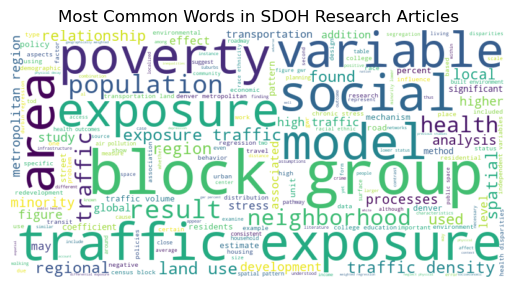

In [78]:
import wordcloud
from wordcloud import WordCloud
wordcloud = WordCloud(width = 800, height = 400, background_color='white').generate(words)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in SDOH Research Articles')
plt.show()